In [ ]:
import pandas as pd
import numpy as np

# Configuración de reproducibilidad
np.random.seed(42)
n_estudiantes = 400

#Generar dataset de hábitos saludables
data = {
    'id_estudiante': range(1, n_estudiantes + 1),
    'edad': np.random.randint(18, 28, n_estudiantes),
    'genero': np.random.choice(['Masculino', 'Femenino', 'No binario'], n_estudiantes),
    'horas_sueno_diarias': np.random.normal(6.5, 1.5, n_estudiantes).round(1),
    'actividad_fisica_min_semana': np.random.randint(0, 400, n_estudiantes),
    'consumo_comida_chatarra': np.random.choice(['Bajo', 'Medio', 'Alto'], n_estudiantes, p=[0.3, 0.5, 0.2]),
    'nivel_estres': np.random.randint(1, 11, n_estudiantes), # Escala 1 al 10
    'promedio_academico': np.random.uniform(1.0, 7.0, n_estudiantes).round(2) # Escala chilena 1.0 a 7.0
}

df = pd.DataFrame(data)

# Introducir algunas inconsistencias leves para la Lección de Limpieza
df.loc[5:15, 'horas_sueno_diarias'] = np.nan
df.loc[20:25, 'promedio_academico'] = 9.9 # Valor erróneo/outlier

print("--- REVISIÓN DEL DATASET UNIVERSITARIO ---")
df.info()
print("\n--- PRIMEROS REGISTROS ---")
print(df.head())

--- REVISIÓN DEL DATASET UNIVERSITARIO ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_estudiante                400 non-null    int64  
 1   edad                         400 non-null    int32  
 2   genero                       400 non-null    str    
 3   horas_sueno_diarias          389 non-null    float64
 4   actividad_fisica_min_semana  400 non-null    int32  
 5   consumo_comida_chatarra      400 non-null    str    
 6   nivel_estres                 400 non-null    int32  
 7   promedio_academico           400 non-null    float64
dtypes: float64(2), int32(3), int64(1), str(2)
memory usage: 20.4 KB

--- PRIMEROS REGISTROS ---
   id_estudiante  edad      genero  horas_sueno_diarias  \
0              1    24   Masculino                  7.1   
1              2    21   Masculino                  4.4   
2         

In [ ]:
#TRATAMIENTO DE OUTLIERS
# El promedio en Chile es de 1.0 a 7.0. El valor 9.9 es un error de digitación.
# Lo corregiremos reemplazándolo por el promedio de la columna (imputación) o limitándolo al máximo (7.0).
df.loc[df['promedio_academico'] > 7.0, 'promedio_academico'] = 7.0

#TRATAMIENTO DE VALORES NULOS (Horas de Sueño)
# Rellenamos los nulos con la media de horas de sueño para mantener la distribución
df['horas_sueno_diarias'] = df['horas_sueno_diarias'].fillna(df['horas_sueno_diarias'].mean())

#ESTADÍSTICA DESCRIPTIVA GENERAL
print("--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
estadisticos = df[['horas_sueno_diarias', 'nivel_estres', 'promedio_academico', 'actividad_fisica_min_semana']].describe()
print(estadisticos.round(2))

# Calculamos la moda para la variable 'consumo_comida_chatarra'
moda_comida = df['consumo_comida_chatarra'].mode()[0]
print(f"\nModa en Consumo de Comida Chatarra: {moda_comida}")

--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
       horas_sueno_diarias  nivel_estres  promedio_academico  \
count               400.00        400.00              400.00   
mean                  6.58          5.63                4.06   
std                   1.63          2.82                1.74   
min                   1.10          1.00                1.01   
25%                   5.60          3.00                2.68   
50%                   6.60          5.00                4.08   
75%                   7.60          8.00                5.52   
max                  11.30         10.00                7.00   

       actividad_fisica_min_semana  
count                       400.00  
mean                        198.57  
std                         121.35  
min                           1.00  
25%                          84.50  
50%                         203.50  
75%                         309.00  
max                         397.00  

Moda en Consumo de Comida Chatarra: Med

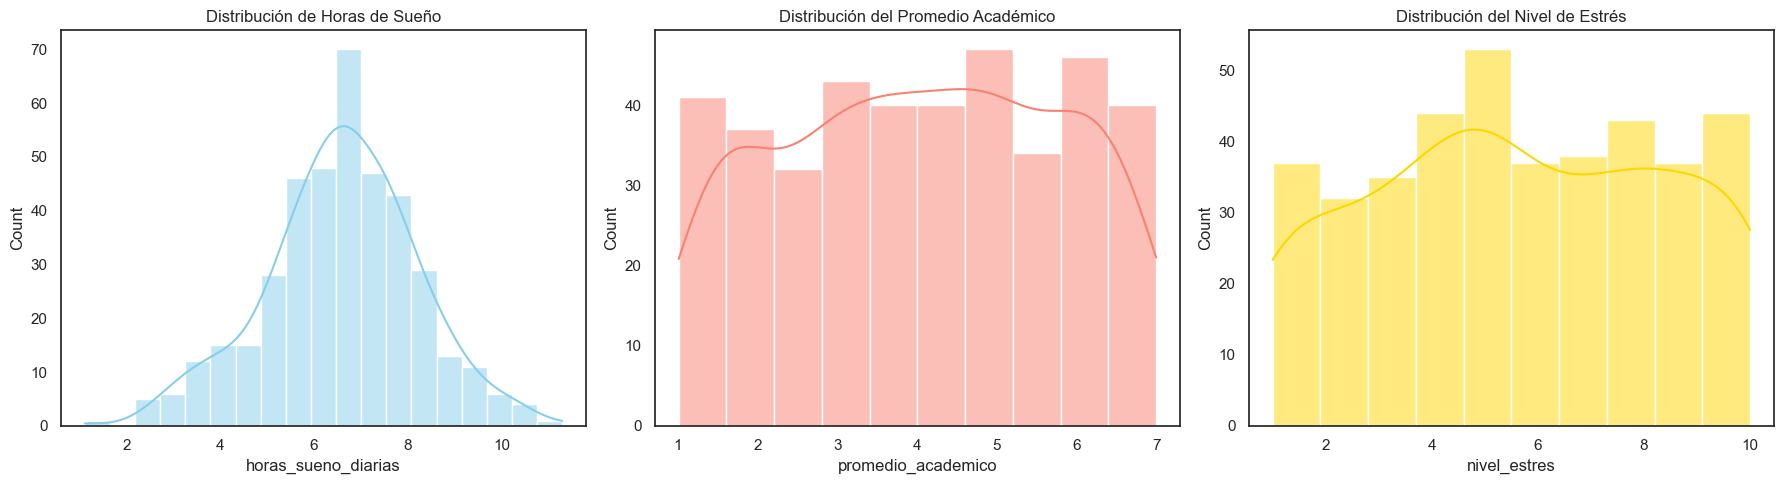

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="white")

# Creamos una figura para ver las distribuciones clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma: Horas de Sueño
sns.histplot(df['horas_sueno_diarias'], kde=True, color="skyblue", ax=axes[0])
axes[0].set_title('Distribución de Horas de Sueño')

# Histograma: Promedio Académico
sns.histplot(df['promedio_academico'], kde=True, color="salmon", ax=axes[1])
axes[1].set_title('Distribución del Promedio Académico')

# Histograma: Nivel de Estrés
sns.histplot(df['nivel_estres'], kde=True, color="gold", ax=axes[2])
axes[2].set_title('Distribución del Nivel de Estrés')

plt.tight_layout()
plt.show()

--- CÁLCULOS DE PROBABILIDAD ---
Probabilidad de dormir < 5 horas: 16.59%
Probabilidad de promedio > 6.0: 13.19%


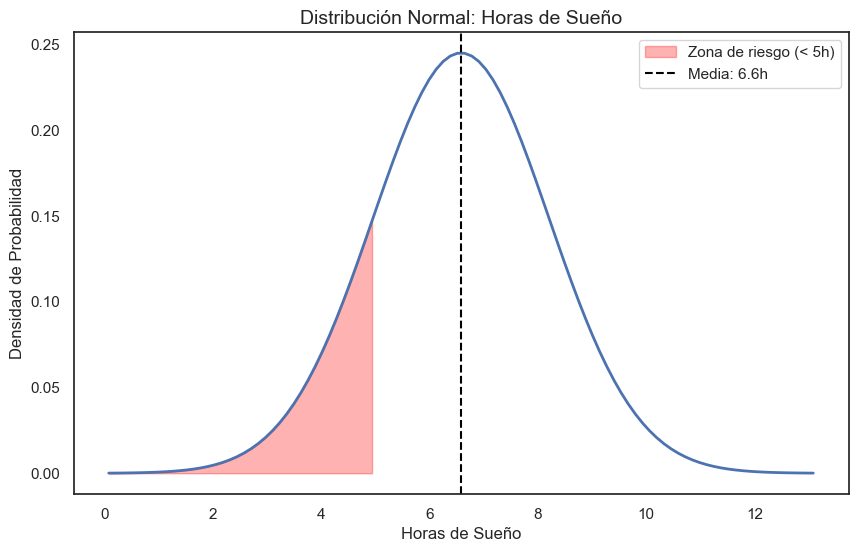

In [ ]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

#Parámetros de las variables (Media y Desviación Estándar)
mu_sueno = df['horas_sueno_diarias'].mean()
sigma_sueno = df['horas_sueno_diarias'].std()

mu_promedio = df['promedio_academico'].mean()
sigma_promedio = df['promedio_academico'].std()

#Cálculos de Probabilidad (Usando la Función de Distribución Acumulada - CDF)
# Probabilidad de dormir menos de 5 horas
prob_sueno_bajo = norm.cdf(5, mu_sueno, sigma_sueno)

#Probabilidad de promedio mayor a 6.0 (1 - CDF)
prob_promedio_alto = 1 - norm.cdf(6, mu_promedio, sigma_promedio)

print(f"--- CÁLCULOS DE PROBABILIDAD ---")
print(f"Probabilidad de dormir < 5 horas: {prob_sueno_bajo:.2%}")
print(f"Probabilidad de promedio > 6.0: {prob_promedio_alto:.2%}")

#Visualización de la Probabilidad (Área bajo la curva)
x = np.linspace(mu_sueno - 4*sigma_sueno, mu_sueno + 4*sigma_sueno, 100)
y = norm.pdf(x, mu_sueno, sigma_sueno)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b', linewidth=2)
plt.fill_between(x, y, where=(x < 5), color='red', alpha=0.3, label='Zona de riesgo (< 5h)')
plt.title('Distribución Normal: Horas de Sueño', fontsize=14)
plt.xlabel('Horas de Sueño')
plt.ylabel('Densidad de Probabilidad')
plt.axvline(mu_sueno, color='black', linestyle='--', label=f'Media: {mu_sueno:.1f}h')
plt.legend()
plt.show()

In [ ]:
import scipy.stats as st

#Función para calcular el intervalo de confianza al 95%
def calcular_intervalo_confianza(data, confianza=0.95):
    n = len(data)
    media = np.mean(data)
    error_estandar = st.sem(data) # Error estándar de la media
    # Usamos la distribución t de Student porque es lo ideal para estimaciones muestrales
    intervalo = st.t.interval(confianza, n-1, loc=media, scale=error_estandar)
    return media, intervalo

#Cálculos
media_s, ic_sueno = calcular_intervalo_confianza(df['horas_sueno_diarias'])
media_p, ic_promedio = calcular_intervalo_confianza(df['promedio_academico'])

print(f"--- ESTIMACIÓN POR INTERVALOS (Confianza 95%) ---")
print(f"Horas de Sueño: Media {media_s:.2f} | IC: ({ic_sueno[0]:.2f}, {ic_sueno[1]:.2f})")
print(f"Promedio Académico: Media {media_p:.2f} | IC: ({ic_promedio[0]:.2f}, {ic_promedio[1]:.2f})")

--- ESTIMACIÓN POR INTERVALOS (Confianza 95%) ---
Horas de Sueño: Media 6.58 | IC: (6.42, 6.74)
Promedio Académico: Media 4.06 | IC: (3.88, 4.23)


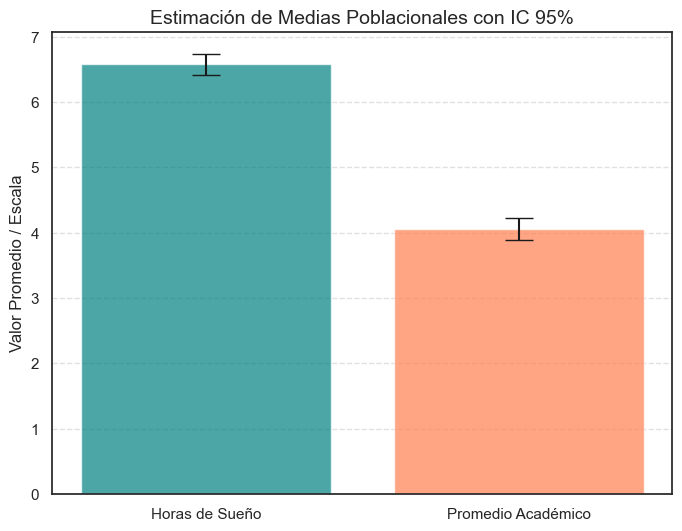

In [ ]:
plt.figure(figsize=(8, 6))
#Gráfico de barras comparando las medias con su respectivo IC
labels = ['Horas de Sueño', 'Promedio Académico']
medias = [media_s, media_p]
#Calculamos la distancia de la media al límite del IC para la barra de error
errores = [media_s - ic_sueno[0], media_p - ic_promedio[0]]

plt.bar(labels, medias, yerr=errores, capsize=10, color=['teal', 'coral'], alpha=0.7)
plt.title('Estimación de Medias Poblacionales con IC 95%', fontsize=14)
plt.ylabel('Valor Promedio / Escala')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from scipy.stats import ttest_ind

#Definir los grupos para la prueba
grupo_duerme_bien = df[df['horas_sueno_diarias'] >= 7]['promedio_academico']
grupo_duerme_poco = df[df['horas_sueno_diarias'] < 7]['promedio_academico']

#Ejecutar la Prueba t de Student
t_stat, p_valor = ttest_ind(grupo_duerme_bien, grupo_duerme_poco, equal_var=False)

print(f"--- RESULTADOS DE LA PRUEBA DE HIPÓTESIS ---")
print(f"Media Grupo >= 7h: {grupo_duerme_bien.mean():.2f}")
print(f"Media Grupo < 7h: {grupo_duerme_poco.mean():.2f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"P-valor: {p_valor:.4f}")

#Lógica de decisión
alfa = 0.05
if p_valor < alfa:
    print("\nCONCLUSIÓN: Se rechaza la Hipótesis Nula (H0).")
    print("Hay evidencia suficiente para afirmar que el sueño influye en las notas.")
else:
    print("\nCONCLUSIÓN: No se rechaza la Hipótesis Nula (H0).")
    print("No hay evidencia suficiente; la diferencia podría deberse al azar.")

--- RESULTADOS DE LA PRUEBA DE HIPÓTESIS ---
Media Grupo >= 7h: 3.96
Media Grupo < 7h: 4.12
Estadístico t: -0.8596
P-valor: 0.3906

CONCLUSIÓN: No se rechaza la Hipótesis Nula (H0).
No hay evidencia suficiente; la diferencia podría deberse al azar.


C:\Users\slayo\AppData\Local\Temp\ipykernel_3088\2274624701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Categoria_Sueno', y='promedio_academico', data=df, palette='Set2')


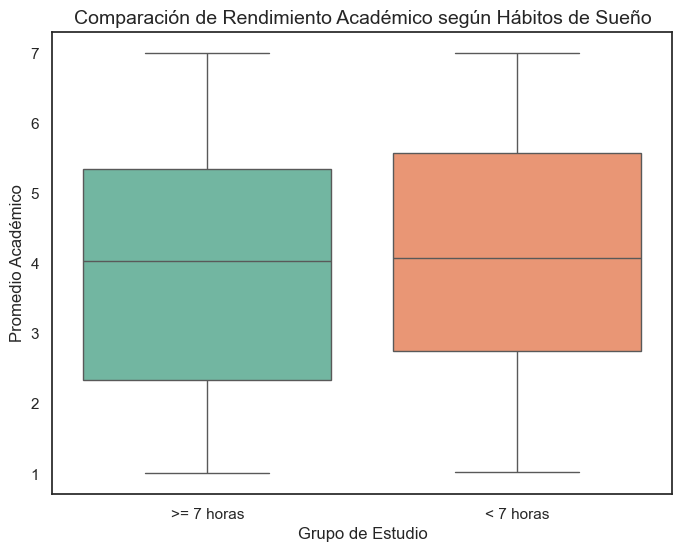

In [ ]:
plt.figure(figsize=(8, 6))
#Creamos una columna temporal para el gráfico
df['Categoria_Sueno'] = df['horas_sueno_diarias'].apply(lambda x: '>= 7 horas' if x >= 7 else '< 7 horas')

sns.boxplot(x='Categoria_Sueno', y='promedio_academico', data=df, palette='Set2')
plt.title('Comparación de Rendimiento Académico según Hábitos de Sueño', fontsize=14)
plt.xlabel('Grupo de Estudio')
plt.ylabel('Promedio Académico')
plt.show()

In [ ]:
import statsmodels.api as sm
from scipy.stats import pearsonr

#MATRIZ DE CORRELACIÓN
#Analizamos la relación entre todas las variables numéricas de salud y estudio
columnas_interes = ['horas_sueno_diarias', 'actividad_fisica_min_semana', 'nivel_estres', 'promedio_academico']
matriz_corr = df[columnas_interes].corr()

print("--- MATRIZ DE CORRELACIÓN (Pearson) ---")
print(matriz_corr.round(3))

#REGRESIÓN LINEAL MÚLTIPLE
#Intentaremos predecir el 'promedio_academico' usando el sueño y el estrés
X = df[['horas_sueno_diarias', 'nivel_estres']]
X = sm.add_constant(X) # Añadimos la constante para el intercepto
y = df['promedio_academico']

modelo_final = sm.OLS(y, X).fit()

print("\n--- RESULTADOS DEL MODELO DE REGRESIÓN ---")
print(modelo_final.summary())

--- MATRIZ DE CORRELACIÓN (Pearson) ---
                             horas_sueno_diarias  actividad_fisica_min_semana  \
horas_sueno_diarias                        1.000                        0.026   
actividad_fisica_min_semana                0.026                        1.000   
nivel_estres                              -0.042                        0.016   
promedio_academico                         0.023                        0.042   

                             nivel_estres  promedio_academico  
horas_sueno_diarias                -0.042               0.023  
actividad_fisica_min_semana         0.016               0.042  
nivel_estres                        1.000              -0.075  
promedio_academico                 -0.075               1.000  

--- RESULTADOS DEL MODELO DE REGRESIÓN ---
                            OLS Regression Results                            
Dep. Variable:     promedio_academico   R-squared:                       0.006
Model:                          

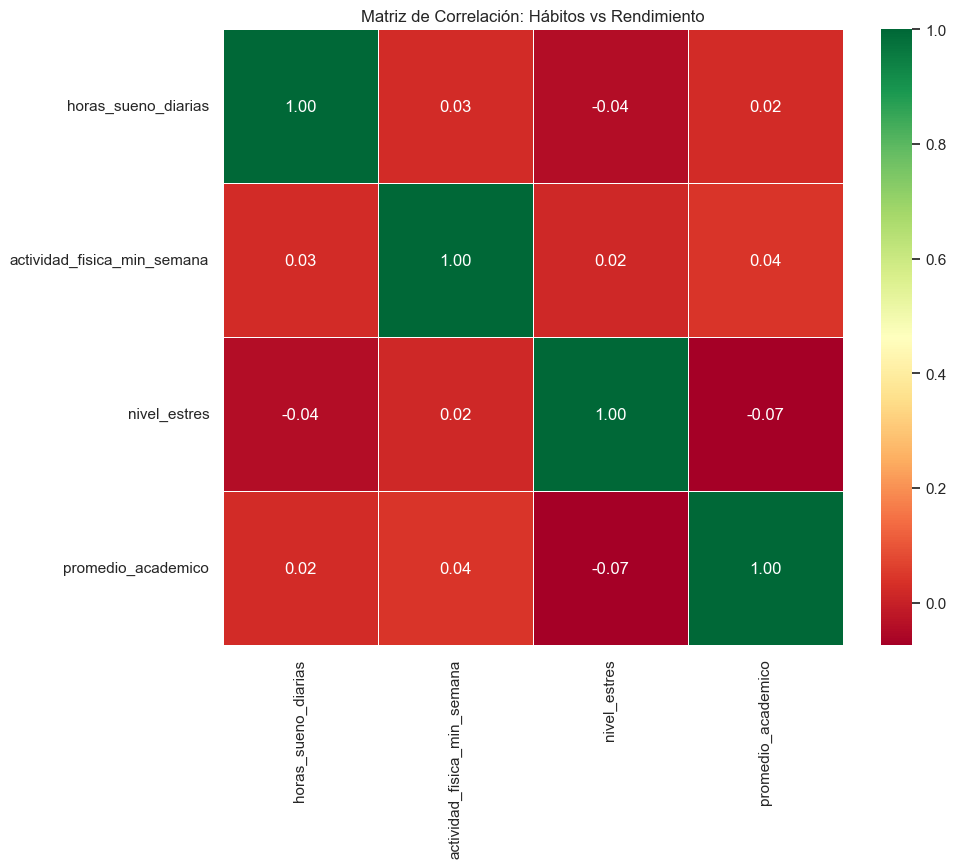

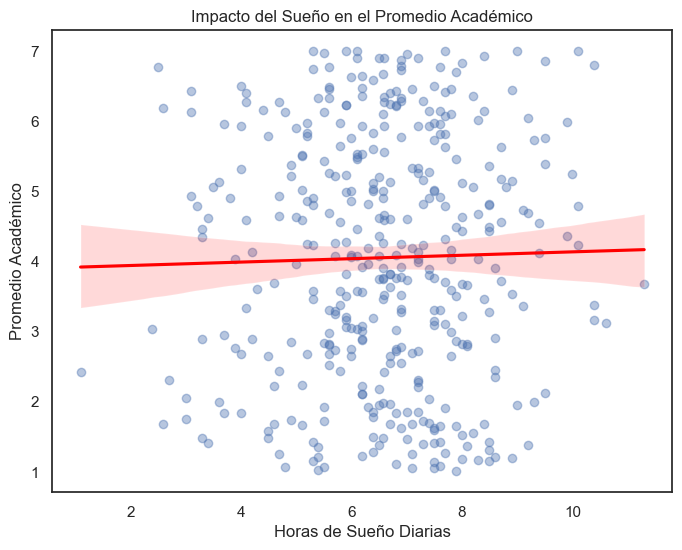

In [ ]:
#Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Hábitos vs Rendimiento')
plt.show()



#Gráfico de Regresión: Sueño vs Promedio
plt.figure(figsize=(8, 6))
sns.regplot(x='horas_sueno_diarias', y='promedio_academico', data=df, 
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Impacto del Sueño en el Promedio Académico')
plt.xlabel('Horas de Sueño Diarias')
plt.ylabel('Promedio Académico')
plt.show()